In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")
df.head(5)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [9]:
df.shape

(235795, 56)

In [10]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [12]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [13]:
df["label"].value_counts(normalize=True)*100

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64

In [14]:
df.isnull().sum().sort_values(ascending=False).head(10) #checking missing values

FILENAME                0
URL                     0
URLLength               0
Domain                  0
DomainLength            0
IsDomainIP              0
TLD                     0
URLSimilarityIndex      0
CharContinuationRate    0
TLDLegitimateProb       0
dtype: int64

In [15]:
df.duplicated().sum() #checking for duplicate values

np.int64(0)

In [16]:
df["URL"].duplicated().sum() #checking for duplicate values in URL column

np.int64(425)

In [17]:
df["URL"].nunique() #checking for unique values in URL column

235370

In [18]:
df.select_dtypes(include="object").columns

C:\Users\swanz\AppData\Local\Temp\ipykernel_25696\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['FILENAME', 'URL', 'Domain', 'TLD', 'Title'], dtype='str')

In [19]:
duplicate_urls = df[df["URL"].duplicated(keep=False)]
duplicate_urls[["URL","label"]].sort_values("URL").head(20)

,URL,label
57609,http://2f3a.reicrut-chat.workers.dev/,0
219489,http://2f3a.reicrut-chat.workers.dev/,0
27166,http://34.149.138.117/,0
227564,http://34.149.138.117/,0
147448,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
189978,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
31955,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
57315,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
126246,http://91.239.125.28/postchs/sms.php,0
197956,http://91.239.125.28/postchs/sms.php,0


In [20]:
url_label_counts = df.groupby("URL")["label"].nunique()
(url_label_counts > 1).sum()

np.int64(0)

In [21]:
df_clean = df.drop_duplicates(
    subset = "URL",
    keep = "first"
).copy()

In [22]:
df_clean.reset_index(drop=True, inplace=True)
df_clean.shape

(235370, 56)

In [23]:
df_clean["URL"].duplicated().sum()

np.int64(0)

In [24]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 235370 entries, 0 to 235369
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235370 non-null  str    
 1   URL                         235370 non-null  str    
 2   URLLength                   235370 non-null  int64  
 3   Domain                      235370 non-null  str    
 4   DomainLength                235370 non-null  int64  
 5   IsDomainIP                  235370 non-null  int64  
 6   TLD                         235370 non-null  str    
 7   URLSimilarityIndex          235370 non-null  float64
 8   CharContinuationRate        235370 non-null  float64
 9   TLDLegitimateProb           235370 non-null  float64
 10  URLCharProb                 235370 non-null  float64
 11  TLDLength                   235370 non-null  int64  
 12  NoOfSubDomain               235370 non-null  int64  
 13  HasObfuscation           

In [25]:
df_clean.drop(columns=["FILENAME"], inplace=True)

In [26]:
df_clean.shape

(235370, 55)

In [27]:
import matplotlib.pyplot as plt

In [28]:
label_names = df_clean["label"].map({
    0: "Phishing",
    1: "Legitimate"
})

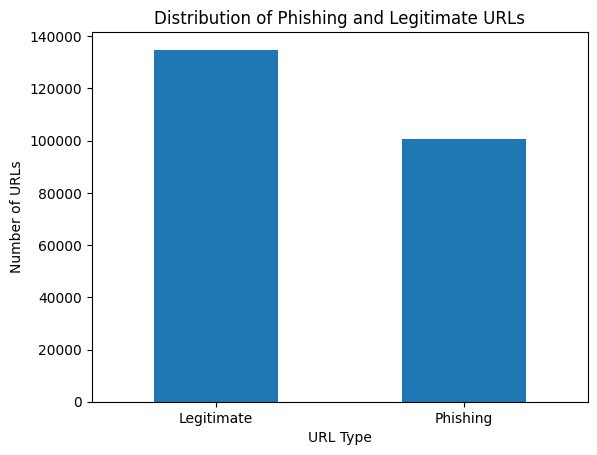

In [29]:
label_names.value_counts().plot(kind="bar")

plt.title("Distribution of Phishing and Legitimate URLs")
plt.xlabel("URL Type")
plt.ylabel("Number of URLs")
plt.xticks(rotation=0)

plt.show()

In [30]:
df_clean.groupby("label")["URLLength"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
label,,,,,
0,100520,45.702845,34.0,13,6097
1,134850,26.228610,26.0,15,57


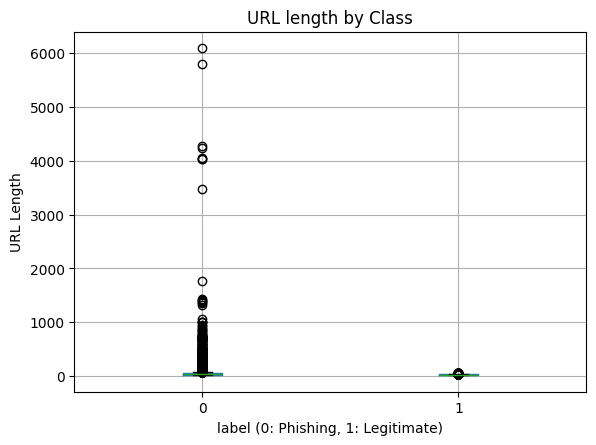

In [31]:
df_clean.boxplot(
    column = "URLLength",
    by = "label"
)

plt.title("URL length by Class")
plt.suptitle("")
plt.xlabel("label (0: Phishing, 1: Legitimate)")
plt.ylabel("URL Length")
plt.show()

In [32]:
df_clean["URLLength"].describe(
    percentiles = [0.90,0.95,0.99]
)

count    235370.000000
mean         34.545516
std          41.332730
min          13.000000
90%          50.000000
95%          73.000000
99%         144.000000
max        6097.000000
Name: URLLength, dtype: float64

In [33]:
df_clean.nlargest(10, "URLLength")[
    ["URL", "URLLength", "label"]
]

,URL,URLLength,label
102859,https://xwebhostapp.github.io/freehost//#eyj2z...,6097,0
9650,https://b4e921f0.sso-mailsrvr-4344e5teed.pages...,5794,0
150704,https://bodhicardstech.com/beta/wx%20qz%20xx%2...,4274,0
145238,https://inspirationalatmospheres.com/qxzrrr%20...,4246,0
152564,https://bodhicardstech.com/beta/wx%20qz%20xx%2...,4054,0
146757,http://www.inspirationalatmospheres.com/qxzrrr...,4036,0
157101,https://inspirationalatmospheres.com/qxzrrr%20...,4032,0
149634,https://ssiol.lt.emlnk.com/prod/link-tracker?n...,3473,0
184540,https://ssiol.lt.emlnk.com/prod/link-tracker?n...,1769,0
233973,https://u31696126.ct.sendgrid.net/ls/click?upn...,1427,0


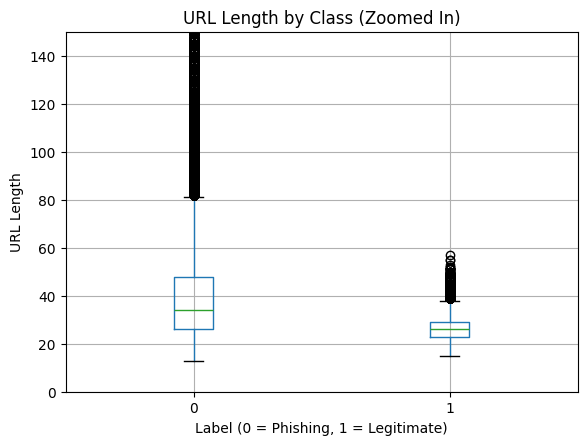

In [34]:
df_clean.boxplot(
    column="URLLength",
    by="label",     
)

plt.title("URL Length by Class (Zoomed In)")
plt.suptitle("")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("URL Length")
plt.ylim(0, 150)  # Adjust the y-axis limit to zoom in
plt.show()

In [35]:
df_clean.groupby("label")["DomainLength"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
label,,,,,
0,100520,24.44415,22.0,4,110
1,134850,19.22861,19.0,8,50


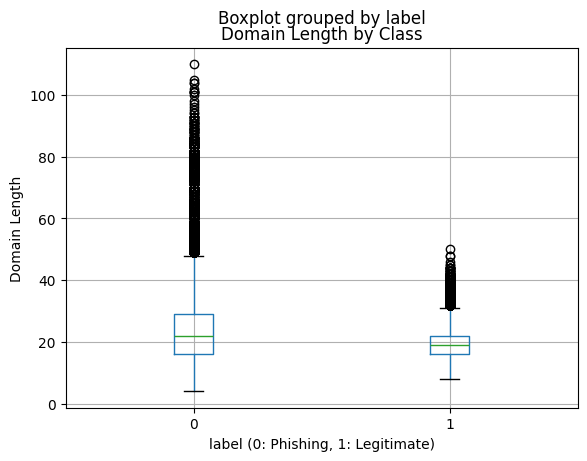

In [36]:
df_clean.boxplot(
    column = "DomainLength",
    by = "label"
)

plt.title("Domain Length by Class")
plt.xlabel("")
plt.xlabel("label (0: Phishing, 1: Legitimate)")
plt.ylabel("Domain Length")
plt.show()

In [37]:
plt.suptitle("")

Text(0.5, 0.98, '')

<Figure size 640x480 with 0 Axes>

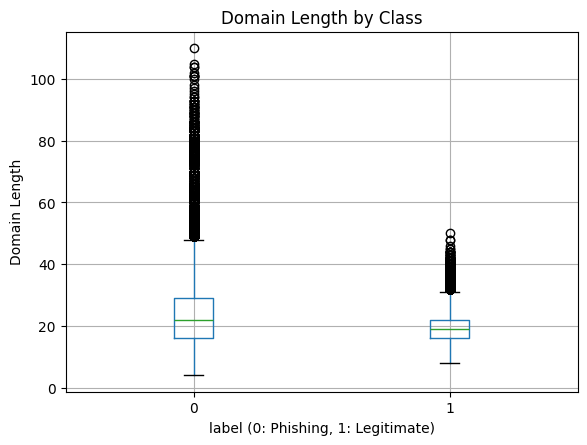

In [38]:
df_clean.boxplot(
    column = "DomainLength",
    by = "label"
)

plt.title("Domain Length by Class")
plt.suptitle("")
plt.xlabel("label (0: Phishing, 1: Legitimate)")
plt.ylabel("Domain Length")
plt.show()

In [39]:
df_clean["IsHTTPS"].value_counts()

IsHTTPS
1    184228
0     51142
Name: count, dtype: int64

In [40]:
pd.crosstab(
    df_clean["label"],
    df_clean["IsHTTPS"]
)

IsHTTPS,0,1
label,,
0,51142,49378
1,0,134850


In [41]:
pd.crosstab(
    df_clean["label"],
    df_clean["IsHTTPS"],
    normalize="index"
)*100

IsHTTPS,0,1
label,,
0,50.877437,49.122563
1,0.000000,100.000000


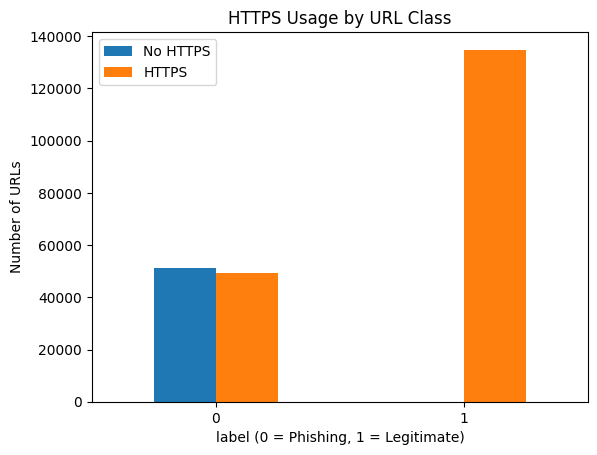

In [42]:
https_table = pd.crosstab(
    df_clean["label"],
    df_clean["IsHTTPS"]
)

https_table.plot(kind="bar")
    
plt.title("HTTPS Usage by URL Class")
plt.xlabel("label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of URLs")
plt.xticks(rotation=0)
plt.legend(["No HTTPS", "HTTPS"])
plt.show()

In [43]:
df_clean["IsDomainIP"].value_counts()

IsDomainIP
0    234734
1       636
Name: count, dtype: int64

In [44]:
pd.crosstab(
    df_clean["label"],
    df_clean["IsDomainIP"],
    normalize="index"
) * 100

IsDomainIP,0,1
label,,
0,99.36729,0.63271
1,100.00000,0.00000


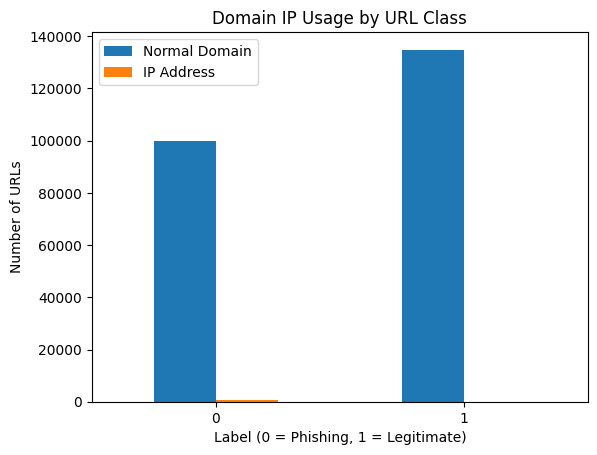

In [45]:
domain_ip_table = pd.crosstab(
    df_clean["label"],
    df_clean["IsDomainIP"]
) 

domain_ip_table.plot(kind="bar")

plt.title("Domain IP Usage by URL Class")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of URLs")
plt.xticks(rotation=0)
plt.legend(["Normal Domain", "IP Address"])
plt.show()

In [46]:
df_clean["HasObfuscation"].value_counts()

HasObfuscation
0    234887
1       483
Name: count, dtype: int64

In [47]:
pd.crosstab(
    df_clean["label"],
    df_clean["HasObfuscation"]
)

HasObfuscation,0,1
label,,
0,100037,483
1,134850,0


In [48]:
pd.crosstab(
    df_clean["label"],
    df_clean["HasObfuscation"],
    normalize="index"
) * 100

HasObfuscation,0,1
label,,
0,99.519499,0.480501
1,100.000000,0.000000


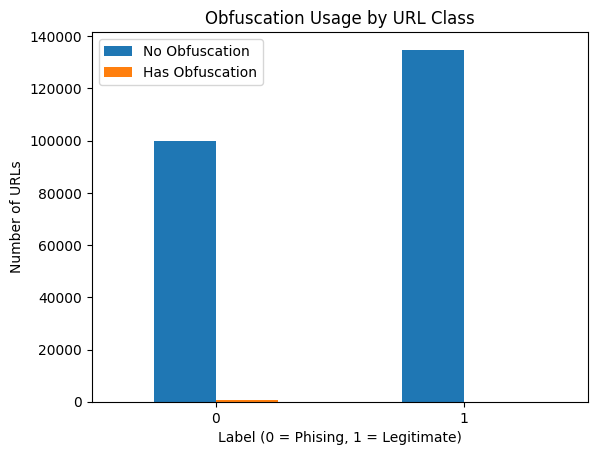

In [49]:
obfuscation_table = pd.crosstab(
    df_clean["label"],
    df_clean["HasObfuscation"]
)

obfuscation_table.plot(kind="bar")

plt.title("Obfuscation Usage by URL Class")
plt.xlabel("Label (0 = Phising, 1 = Legitimate)")
plt.ylabel("Number of URLs")
plt.xticks(rotation = 0)
plt.legend(["No Obfuscation", "Has Obfuscation"])
plt.show()

In [50]:
df_clean.groupby("label")["NoOfSubDomain"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
label,,,,,
0,100520,1.169379,1.0,0,10
1,134850,1.161661,1.0,1,4


In [51]:
pd.crosstab(
    df_clean["label"],
    df_clean["NoOfSubDomain"]
)

NoOfSubDomain,0,1,2,3,4,5,6,7,8,10
label,,,,,,,,,,
0,13904,63281,18050,3414,1500,336,21,5,4,5
1,0,114861,18238,1691,60,0,0,0,0,0


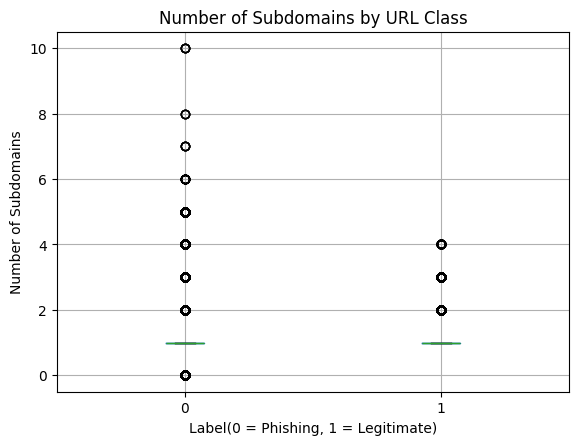

In [52]:
df_clean.boxplot(
    column="NoOfSubDomain",
    by="label"
)

plt.title("Number of Subdomains by URL Class")
plt.suptitle("")
plt.xlabel("Label(0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of Subdomains")
plt.show()

In [53]:
df_clean.groupby("label")["NoOfDegitsInURL"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
label,,,,,
0,100520,4.324194,0.0,0,2011
1,134850,0.050597,0.0,0,8


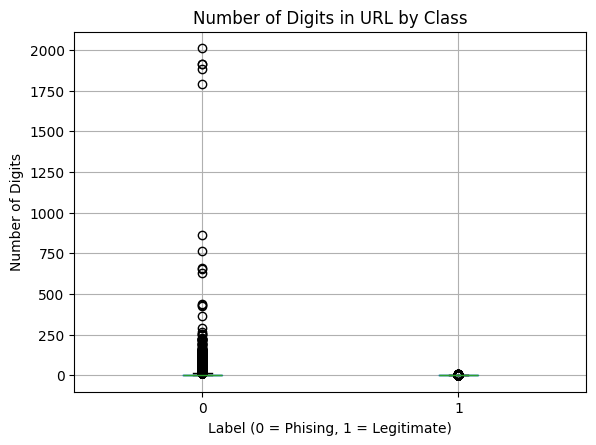

In [54]:
df_clean.boxplot(
    column = "NoOfDegitsInURL",
    by="label"
)

plt.title("Number of Digits in URL by Class")
plt.suptitle("")
plt.xlabel("Label (0 = Phising, 1 = Legitimate)")
plt.ylabel("Number of Digits")
plt.show()

In [55]:
digit_presence = pd.crosstab(
    df_clean["label"],
    df_clean["NoOfDegitsInURL"] > 0,
    normalize="index"
) * 100

digit_presence

NoOfDegitsInURL,False,True
label,,
0,52.608436,47.391564
1,97.360030,2.639970


In [56]:
df_clean.groupby("label")["NoOfLettersInURL"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
label,,,,,
0,100520,28.088669,20.0,0,5191
1,134850,12.933059,13.0,1,44


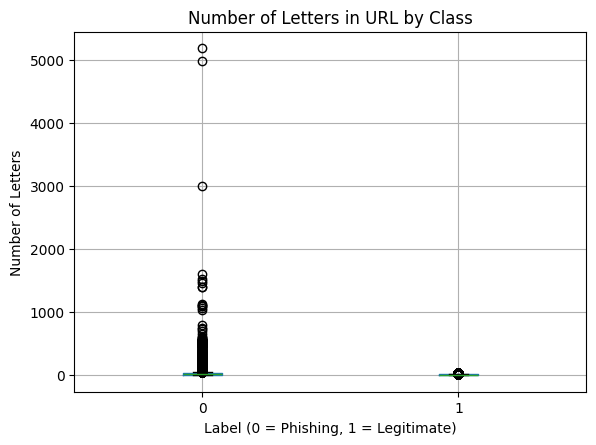

In [57]:
df_clean.boxplot(
    column="NoOfLettersInURL",
    by="label"
)

plt.title("Number of Letters in URL by Class")
plt.suptitle("")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of Letters")
plt.show()

In [58]:
df_clean.groupby("label")["LetterRatioInURL"].agg([
    "mean",
    "median",
    "min",
    "max"
])

,mean,median,min,max
label,,,,
0,0.568128,0.577,0.000,0.926
1,0.476705,0.480,0.056,0.772


In [59]:
correlation_features = df_clean[
    [
        "URLLength",
        "NoOfLettersInURL",
        "NoOfDegitsInURL",
        "LetterRatioInURL"
    ]
]

In [60]:
correlation_features.corr()

,URLLength,NoOfLettersInURL,NoOfDegitsInURL,LetterRatioInURL
URLLength,1.000000,0.956046,0.835966,0.312243
NoOfLettersInURL,0.956046,1.000000,0.648154,0.416452
NoOfDegitsInURL,0.835966,0.648154,1.000000,0.045009
LetterRatioInURL,0.312243,0.416452,0.045009,1.000000


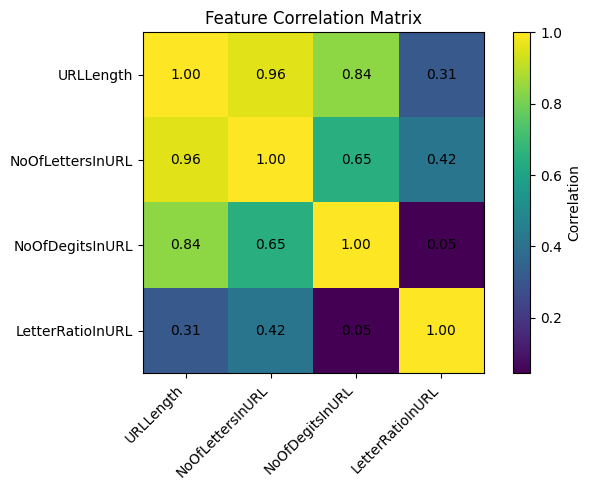

In [61]:
corr_matrix = correlation_features.corr()

plt.figure(figsize=(7,5))
plt.imshow(corr_matrix)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.colorbar(label="Correlation")

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [62]:
numeric_df = df_clean.select_dtypes(include=["int64","float64"])
label_correlation = numeric_df.corr()["label"].sort_values(ascending=False)
label_correlation

label                         1.000000
URLSimilarityIndex            0.860342
HasSocialNet                  0.783882
HasCopyrightInfo              0.743197
HasDescription                0.690011
IsHTTPS                       0.610253
DomainTitleMatchScore         0.584204
HasSubmitButton               0.578816
IsResponsive                  0.548977
URLTitleMatchScore            0.538844
HasHiddenFields               0.507715
HasFavicon                    0.493607
URLCharProb                   0.469521
CharContinuationRate          0.467162
HasTitle                      0.460337
Robots                        0.392461
NoOfJS                        0.373162
Pay                           0.359724
NoOfSelfRef                   0.315867
NoOfImage                     0.274365
LineOfCode                    0.271970
NoOfExternalRef               0.258339
NoOfiFrame                    0.225567
Bank                          0.188886
HasExternalFormSubmit         0.167398
HasPasswordField         

In [63]:
label_correlation = (
    numeric_df.corr()["label"]
    .drop("label")
    .sort_values(ascending=False)
)

label_correlation

URLSimilarityIndex            0.860342
HasSocialNet                  0.783882
HasCopyrightInfo              0.743197
HasDescription                0.690011
IsHTTPS                       0.610253
DomainTitleMatchScore         0.584204
HasSubmitButton               0.578816
IsResponsive                  0.548977
URLTitleMatchScore            0.538844
HasHiddenFields               0.507715
HasFavicon                    0.493607
URLCharProb                   0.469521
CharContinuationRate          0.467162
HasTitle                      0.460337
Robots                        0.392461
NoOfJS                        0.373162
Pay                           0.359724
NoOfSelfRef                   0.315867
NoOfImage                     0.274365
LineOfCode                    0.271970
NoOfExternalRef               0.258339
NoOfiFrame                    0.225567
Bank                          0.188886
HasExternalFormSubmit         0.167398
HasPasswordField              0.139162
NoOfEmptyRef             

In [64]:
label_correlation.abs().sort_values(ascending=False).head(15)

URLSimilarityIndex       0.860342
HasSocialNet             0.783882
HasCopyrightInfo         0.743197
HasDescription           0.690011
IsHTTPS                  0.610253
DomainTitleMatchScore    0.584204
HasSubmitButton          0.578816
IsResponsive             0.548977
URLTitleMatchScore       0.538844
SpacialCharRatioInURL    0.533003
HasHiddenFields          0.507715
HasFavicon               0.493607
URLCharProb              0.469521
CharContinuationRate     0.467162
HasTitle                 0.460337
Name: label, dtype: float64

In [65]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DigitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

In [66]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",  # correct column name in df_clean
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

X = df_clean[url_features]
y = df_clean["label"]

In [67]:
print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Missing values:", X.isnull().sum().sum())

X shape:  (235370, 18)
y shape:  (235370,)
Missing values: 0


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state= 42,
    stratify = y
)

In [70]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (188296, 18)
X_test: (47074, 18)
y_train: (188296,)
y_test: (47074,)


In [71]:
print("Training distribution")
print(y_train.value_counts(normalize=True)*100)
print("\nTesting distribution")
print(y_test.value_counts(normalize=True)*100)

Training distribution
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

Testing distribution
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [72]:
print("Training distribution:")
print(y_train.value_counts(normalize=True)*100)
print("\nTesting distribution:")
print(y_test.value_counts(normalize=True)*100)

Training distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

Testing distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [73]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [74]:
y_pred = log_model.predict(X_test)

In [75]:
print("Predicted: ", y_pred[:10])
print("Actual: ", y_test.iloc[:10].values)

Predicted:  [0 1 1 0 0 1 1 1 0 0]
Actual:  [0 1 1 0 0 1 1 1 0 0]


In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %", accuracy * 100)

Accuracy: 0.9974295789607851
Accuracy % 99.74295789607851


In [77]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Phishing", "Legitimate"]
))

              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20104
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [78]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19986   118]
 [    3 26967]]


In [79]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [80]:
tree_pred = tree_model.predict(X_test)

In [81]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy:", tree_accuracy * 100)

Decision Tree Accuracy: 0.9974083358117007
Decision Tree Accuracy: 99.74083358117008


In [82]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    tree_pred,
    target_names=["Phishing", "Legitimate"]
))

              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20104
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [83]:
from sklearn.metrics import confusion_matrix

tree_cm = confusion_matrix(y_test, tree_pred)

print(tree_cm)

[[19999   105]
 [   17 26953]]


In [84]:
tree_train_pred = tree_model.predict(X_train)

tree_train_accuracy = accuracy_score(
    y_train,
    tree_train_pred
)

print("Training Accuracy:", tree_train_accuracy * 100)
print("Testing Accuracy:", tree_accuracy * 100)

Training Accuracy: 99.83430343714153
Testing Accuracy: 99.74083358117008


In [85]:
tree_train_pred = tree_model.predict(X_train)

print(
    "Decision Tree Training Accuracy:",
    accuracy_score(y_train, tree_train_pred) * 100
)

print(
    "Decision Tree Testing Accuracy:",
    accuracy_score(y_test, tree_pred) * 100
)

Decision Tree Training Accuracy: 99.83430343714153
Decision Tree Testing Accuracy: 99.74083358117008


In [86]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [87]:
rf_pred = rf_model.predict(X_test)

In [88]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy:", rf_accuracy * 100)

Random Forest Accuracy: 0.9974295789607851
Random Forest Accuracy: 99.74295789607851


In [89]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Phishing", "Legitimate"]
))

              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20104
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [90]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[20001   103]
 [   18 26952]]


In [91]:
rf_train_pred = rf_model.predict(X_train)

print(
    "Random Forest Training Accuracy:",
    accuracy_score(y_train, rf_train_pred) * 100
)

print(
    "Random Forest Testing Accuracy:",
    accuracy_score(y_test, rf_pred) * 100
)

Random Forest Training Accuracy: 99.83430343714153
Random Forest Testing Accuracy: 99.74295789607851


In [92]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}) 

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
17,IsHTTPS,3.874545e-01
15,NoOfOtherSpecialCharsInURL,1.373018e-01
10,NoOfDegitsInURL,9.170531e-02
9,LetterRatioInURL,7.596898e-02
11,DegitRatioInURL,6.993862e-02
0,URLLength,6.376021e-02
16,SpacialCharRatioInURL,5.190557e-02
8,NoOfLettersInURL,5.051815e-02
4,NoOfSubDomain,3.799083e-02
1,DomainLength,2.465530e-02


In [93]:
feature_importance["Importance"].sum()

np.float64(1.0)

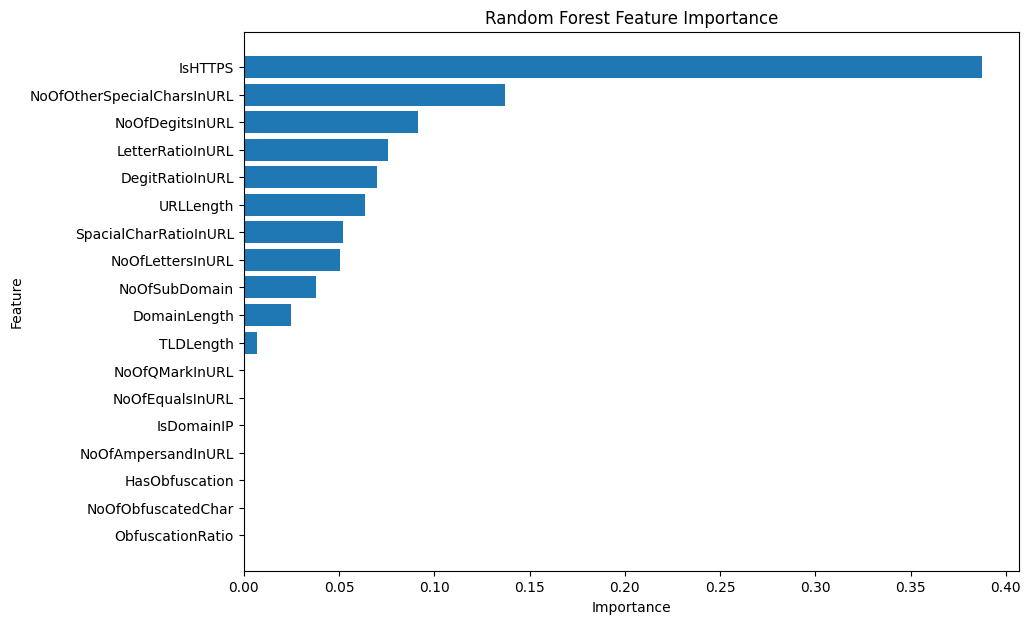

In [94]:
plt.figure(figsize=(10,7))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [95]:
pos_label = 0

In [96]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models_comparison = pd.DataFrame({
    "Model": [
        "LogisticRegression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
],

    "Phishing Precision": [
        precision_score(y_test, y_pred, pos_label=0),
        precision_score(y_test, tree_pred, pos_label=0),
        precision_score(y_test, rf_pred, pos_label=0)
],

    "Phishing Recall": [
        recall_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, tree_pred, pos_label=0),
        recall_score(y_test, rf_pred, pos_label=0)
],

    "Phishing F1": [
        f1_score(y_test, y_pred, pos_label=0),
        f1_score(y_test, tree_pred, pos_label=0),
        f1_score(y_test, rf_pred, pos_label=0)
]

})

models_comparison

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
0,LogisticRegression,0.997430,0.999850,0.994131,0.996982
1,Decision Tree,0.997408,0.999151,0.994777,0.996959
2,Random Forest,0.997430,0.999101,0.994877,0.996984


In [97]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, recall_score

In [98]:
phishing_recall_scorer = make_scorer(
    recall_score,
    pos_label=0
)

In [99]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [100]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=phishing_recall_scorer,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean Phishing Recall": scores.mean(),
        "Std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

cv_results

,Model,Mean Phishing Recall,Std
0,Logistic Regression,0.994528,0.000530
1,Decision Tree,0.994802,0.000372
2,Random Forest,0.994864,0.000419


In [101]:
import joblib

In [102]:
model_bundle = {
    "model": rf_model,
    "features": url_features
}

joblib.dump(
    model_bundle,
    "../models/phishing_random_forest.pkl"
)

['../models/phishing_random_forest.pkl']

In [103]:
import os

os.path.exists("../models/phishing_random_forest.pkl")

True

In [104]:
loaded_bundle = joblib.load(
    "../models/phishing_random_forest.pkl"
)

loaded_model = loaded_bundle["model"]
loaded_features = loaded_bundle["features"]

print(loaded_features)

['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']


In [105]:
sample = df_clean.iloc[0]
print("URL: ")
print(sample["URL"])
print("\nFeatures: ")
print(sample[url_features])

URL: 
https://www.southbankmosaics.com

Features: 
URLLength                        31
DomainLength                     24
IsDomainIP                        0
TLDLength                         3
NoOfSubDomain                     1
HasObfuscation                    0
NoOfObfuscatedChar                0
ObfuscationRatio                0.0
NoOfLettersInURL                 18
LetterRatioInURL              0.581
NoOfDegitsInURL                   0
DegitRatioInURL                 0.0
NoOfEqualsInURL                   0
NoOfQMarkInURL                    0
NoOfAmpersandInURL                0
NoOfOtherSpecialCharsInURL        1
SpacialCharRatioInURL         0.032
IsHTTPS                           1
Name: 0, dtype: object


In [106]:
url = sample["URL"]

print("URLLength:", len(url))
print("Letters:", sum(c.isalpha() for c in url))
print("Digits:", sum(c.isdigit() for c in url))
print("Equals:", url.count("="))
print("Question Marks:", url.count("?"))
print("Ampersands:", url.count("&"))

URLLength: 32
Letters: 27
Digits: 0
Equals: 0
Question Marks: 0
Ampersands: 0


In [107]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.feature_extraction import extract_url_features

In [108]:
import sys 
sys.path.append("../src")
from src.feature_extraction import extract_url_features

In [109]:
test_url = "https://www.southbankmosaics.com"
features = extract_url_features(test_url)
features

{'URLLength': 32,
 'DomainLength': 24,
 'IsDomainIP': 0,
 'TLDLength': 3,
 'NoOfSubDomain': 1,
 'HasObfuscation': 0,
 'NoOfObfuscatedChar': 0,
 'ObfuscationRatio': 0.0,
 'NoOfLettersInURL': 27,
 'LetterRatioInURL': 0.84375,
 'NoOfDegitsInURL': 0,
 'DigitRatioInURL': 0.0,
 'NoOfEqualsInURL': 0,
 'NoOfQMarkInURL': 0,
 'NoOfAmpersandInURL': 0,
 'NoOfOtherSpecialCharsInURL': 0,
 'SpacialCharRatioInURL': 0.15625,
 'IsHTTPS': 1}

In [110]:
feature_rows = df_clean["URL"].apply(extract_url_features)

In [111]:
X_url = pd.DataFrame(feature_rows.tolist())

In [112]:
y_url = df_clean["label"].copy()

In [113]:
print("X shape:", X_url.shape)
print("y shape:", y_url.shape)
print("Missing values:", X_url.isnull().sum().sum())
X_url.head()

X shape: (235370, 18)
y shape: (235370,)
Missing values: 0


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DigitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,32,24,0,3,1,0,0,0.0,27,0.843750,0,0.0,0,0,0,0,0.156250,1
1,24,16,0,2,1,0,0,0.0,18,0.750000,0,0.0,0,0,0,1,0.250000,1
2,30,22,0,2,2,0,0,0.0,24,0.800000,0,0.0,0,0,0,0,0.200000,1
3,27,19,0,3,1,0,0,0.0,22,0.814815,0,0.0,0,0,0,0,0.185185,1
4,34,26,0,3,1,0,0,0.0,29,0.852941,0,0.0,0,0,0,0,0.147059,1


In [114]:
print(X_url.columns.tolist())

['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DigitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']


In [115]:
print("Correct feature order:", X_url.columns.tolist() == url_features)

Correct feature order: False


In [116]:
print("X_url columns:")
print(X_url.columns.tolist())

print("\nExpected columns:")
print(url_features)

X_url columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DigitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']

Expected columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']


In [117]:
for i, (actual, expected) in enumerate(
    zip(X_url.columns.tolist(), url_features)
):
    if actual != expected:
        print(
            f"Position {i}: "
            f"actual = {actual}, expected = {expected}"
        )

Position 11: actual = DigitRatioInURL, expected = DegitRatioInURL


In [118]:
print(
    "Missing from X_url:",
    set(url_features) - set(X_url.columns)
)

print(
    "Extra in X_url:",
    set(X_url.columns) - set(url_features)
)

Missing from X_url: {'DegitRatioInURL'}
Extra in X_url: {'DigitRatioInURL'}


In [119]:
url_features = [
    "DigitRatioInURL" if feature == "DegitRatioInURL" else feature
    for feature in url_features
]

print(
    "Correct feature order:",
    X_url.columns.tolist() == url_features
)

Correct feature order: True


In [120]:
print(url_features)

['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DigitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']


In [121]:
from sklearn.model_selection import train_test_split

X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
    X_url,
    y_url,
    test_size=0.20,
    random_state=42,
    stratify=y_url
)

In [122]:
print("X_train_url:", X_train_url.shape)
print("X_test_url:", X_test_url.shape)
print("y_train_url:", y_train_url.shape)
print("y_test_url:", y_test_url.shape)

X_train_url: (188296, 18)
X_test_url: (47074, 18)
y_train_url: (188296,)
y_test_url: (47074,)


In [123]:
from sklearn.linear_model import LogisticRegression

log_model_url = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model_url.fit(X_train_url, y_train_url)

log_pred_url = log_model_url.predict(X_test_url)

In [124]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_url, log_pred_url))

print(classification_report(
    y_test_url,
    log_pred_url,
    target_names=["Phishing", "Legitimate"]
))

print(confusion_matrix(y_test_url, log_pred_url))

Accuracy: 0.9931597059948166
              precision    recall  f1-score   support

    Phishing       1.00      0.98      0.99     20104
  Legitimate       0.99      1.00      0.99     26970

    accuracy                           0.99     47074
   macro avg       0.99      0.99      0.99     47074
weighted avg       0.99      0.99      0.99     47074

[[19793   311]
 [   11 26959]]


In [125]:
from sklearn.tree import DecisionTreeClassifier

tree_model_url = DecisionTreeClassifier(
    random_state=42
)

tree_model_url.fit(
    X_train_url,
    y_train_url
)

tree_pred_url = tree_model_url.predict(
    X_test_url
)

In [126]:
print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test_url, tree_pred_url)
)

print(classification_report(
    y_test_url,
    tree_pred_url,
    target_names=["Phishing", "Legitimate"]
))

print(confusion_matrix(
    y_test_url,
    tree_pred_url
))

Decision Tree Accuracy: 0.995199048306921
              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20104
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      0.99      1.00     47074
weighted avg       1.00      1.00      1.00     47074

[[19923   181]
 [   45 26925]]


In [127]:
from sklearn.ensemble import RandomForestClassifier

rf_model_url = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model_url.fit(
    X_train_url,
    y_train_url
)

rf_pred_url = rf_model_url.predict(
    X_test_url
)

In [128]:
print(
    "Random Forest Accuracy:",
    accuracy_score(y_test_url, rf_pred_url)
)

print(classification_report(
    y_test_url,
    rf_pred_url,
    target_names=["Phishing", "Legitimate"]
))

print(confusion_matrix(
    y_test_url,
    rf_pred_url
))

Random Forest Accuracy: 0.9952627777541743
              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20104
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      0.99      1.00     47074
weighted avg       1.00      1.00      1.00     47074

[[19929   175]
 [   48 26922]]


In [129]:
deploy_models_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test_url, log_pred_url),
        accuracy_score(y_test_url, tree_pred_url),
        accuracy_score(y_test_url, rf_pred_url)
    ],

    "Phishing Precision": [
        precision_score(y_test_url, log_pred_url, pos_label=0),
        precision_score(y_test_url, tree_pred_url, pos_label=0),
        precision_score(y_test_url, rf_pred_url, pos_label=0)
    ],

    "Phishing Recall": [
        recall_score(y_test_url, log_pred_url, pos_label=0),
        recall_score(y_test_url, tree_pred_url, pos_label=0),
        recall_score(y_test_url, rf_pred_url, pos_label=0)
    ],

    "Phishing F1": [
        f1_score(y_test_url, log_pred_url, pos_label=0),
        f1_score(y_test_url, tree_pred_url, pos_label=0),
        f1_score(y_test_url, rf_pred_url, pos_label=0)
    ]
})

deploy_models_comparison

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
0,Logistic Regression,0.993160,0.999445,0.984530,0.991931
1,Decision Tree,0.995199,0.997746,0.990997,0.994360
2,Random Forest,0.995263,0.997597,0.991295,0.994436


In [130]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, recall_score

phishing_recall_scorer = make_scorer(
    recall_score,
    pos_label=0
)

cv_url = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [131]:
deploy_models = {
    "Logistic Regression": log_model_url,
    "Decision Tree": tree_model_url,
    "Random Forest": rf_model_url
}

deploy_cv_results = []

for name, model in deploy_models.items():

    scores = cross_val_score(
        model,
        X_train_url,
        y_train_url,
        cv=cv_url,
        scoring=phishing_recall_scorer,
        n_jobs=-1
    )

    deploy_cv_results.append({
        "Model": name,
        "Mean Phishing Recall": scores.mean(),
        "Std": scores.std()
    })

deploy_cv_results = pd.DataFrame(deploy_cv_results)

deploy_cv_results

,Model,Mean Phishing Recall,Std
0,Logistic Regression,0.984916,0.000602
1,Decision Tree,0.990611,0.000645
2,Random Forest,0.990972,0.000701


In [132]:
import joblib

final_model_bundle = {
    "model": rf_model_url,
    "features": url_features
}

joblib.dump(
    final_model_bundle,
    "../models/phishing_random_forest_final.pkl"
)

['../models/phishing_random_forest_final.pkl']

In [133]:
import os

print(
    os.path.exists(
        "../models/phishing_random_forest_final.pkl"
    )
)

True


In [134]:
loaded_bundle = joblib.load(
    "../models/phishing_random_forest_final.pkl"
)

loaded_model = loaded_bundle["model"]
loaded_features = loaded_bundle["features"]

print(type(loaded_model))
print(loaded_features)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DigitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']


In [135]:
url_features_no_https = [
    feature
    for feature in X_url.columns
    if feature != "IsHTTPS"
]

print(url_features_no_https)
print("Number of features:", len(url_features_no_https))

['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DigitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL']
Number of features: 17


In [137]:
print(url_features_no_https)
print("Number of features:", len(url_features_no_https))

['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DigitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL']
Number of features: 17


In [138]:
X_no_https = X_url[url_features_no_https]

In [139]:
X_train_no_https, X_test_no_https, y_train_no_https, y_test_no_https = train_test_split(
    X_no_https,
    y_url,
    test_size=0.20,
    random_state=42,
    stratify=y_url
)

In [140]:
rf_no_https = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_no_https.fit(
    X_train_no_https,
    y_train_no_https
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [141]:
rf_no_https_pred = rf_no_https.predict(
    X_test_no_https
)

In [142]:
print(
    "Accuracy:",
    accuracy_score(
        y_test_no_https,
        rf_no_https_pred
    )
)

print(classification_report(
    y_test_no_https,
    rf_no_https_pred,
    target_names=["Phishing", "Legitimate"]
))

print(confusion_matrix(
    y_test_no_https,
    rf_no_https_pred
))

Accuracy: 0.9943918086417131
              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20104
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           0.99     47074
   macro avg       0.99      0.99      0.99     47074
weighted avg       0.99      0.99      0.99     47074

[[19910   194]
 [   70 26900]]


In [144]:
test_urls = [
    "http://www.google.com",
    "https://www.google.com",
    "http://example.com",
    "https://example.com",
    "http://192.168.1.50/login123?verify=1"
]

for url in test_urls:
    features = extract_url_features(url)

    # Model WITH HTTPS
    full_input = pd.DataFrame([features])[X_url.columns]
    pred_with_https = rf_model_url.predict(full_input)[0]

    # Model WITHOUT HTTPS
    no_https_input = pd.DataFrame([features])[url_features_no_https]
    pred_no_https = rf_no_https.predict(no_https_input)[0]

    print("\nURL:", url)
    print(
        "With HTTPS feature:",
        "Legitimate" if pred_with_https == 1 else "Phishing"
    )
    print(
        "Without HTTPS feature:",
        "Legitimate" if pred_no_https == 1 else "Phishing"
    )


URL: http://www.google.com
With HTTPS feature: Phishing
Without HTTPS feature: Phishing

URL: https://www.google.com
With HTTPS feature: Legitimate
Without HTTPS feature: Legitimate

URL: http://example.com
With HTTPS feature: Phishing
Without HTTPS feature: Phishing

URL: https://example.com
With HTTPS feature: Phishing
Without HTTPS feature: Phishing

URL: http://192.168.1.50/login123?verify=1
With HTTPS feature: Phishing
Without HTTPS feature: Phishing
